# NBA Prediction Model

**Goal:** Build a model that predicts whether the home team will win an NBA game.

1. Data preparation
2. Determine features
3. Train model
4. Evaluate and improve

> **Read me first (added when publishing, Sept 2026).** This notebook is my original exploration, kept as-is with its outputs. The final model lives in `src/`, and the numbers in the README come from `python -m src.backtest`, not from this notebook. Caveats I found on review:
> - **Cells 4–40 use the Kaggle `games.csv`**, which includes preseason and playoff games and a few duplicate game IDs. In that section, `home_win_pct_last10` / `home_rest_days` are grouped by `HOME_TEAM_ID`, so they measure a team's last 10 *home* games / days since its last *home* game, not all games. The back-to-back flags built from them are therefore wrong. The 55.6% baseline and the 61–62.5% accuracies come from this earlier model.
> - **`cross_val_score(..., cv=5)`** uses stratified folds that train on *future* games, so those CV numbers aren't time-aware. The backtest in `src/backtest.py` uses season-by-season walk-forward and `TimeSeriesSplit` instead.
> - The *"Advanced (715 games): 69.9%"* printed in cell 57 is a hard-coded note; the cell 48 run above it shows 67.3%.
> - The 12-feature API model (cells 42+) is the one used in production; its rolling features use `shift(1)` and were verified leak-free.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Plot Settings
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

## Data Preparation
Using real NBA game data from a kaggle dataset. 
https://www.kaggle.com/datasets/nathanlauga/nba-games?resource=download

In [2]:
df = pd.read_csv('../data/raw/kaggle/games.csv')  # Kaggle file, not in repo; see data/README.md
print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")

26,651 rows, 21 columns


## EDA and cleaning data

In [4]:
print(df.columns.tolist())
df.head(3)

['GAME_DATE_EST', 'GAME_ID', 'GAME_STATUS_TEXT', 'HOME_TEAM_ID', 'VISITOR_TEAM_ID', 'SEASON', 'TEAM_ID_home', 'PTS_home', 'FG_PCT_home', 'FT_PCT_home', 'FG3_PCT_home', 'AST_home', 'REB_home', 'TEAM_ID_away', 'PTS_away', 'FG_PCT_away', 'FT_PCT_away', 'FG3_PCT_away', 'AST_away', 'REB_away', 'HOME_TEAM_WINS']


,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,FG3_PCT_home,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-22,22200477,Final,1610612740,1610612759,2022,1610612740,126.0,0.484,0.926,0.382,25.0,46.0,1610612759,117.0,0.478,0.815,0.321,23.0,44.0,1
1,2022-12-22,22200478,Final,1610612762,1610612764,2022,1610612762,120.0,0.488,0.952,0.457,16.0,40.0,1610612764,112.0,0.561,0.765,0.333,20.0,37.0,1
2,2022-12-21,22200466,Final,1610612739,1610612749,2022,1610612739,114.0,0.482,0.786,0.313,22.0,37.0,1610612749,106.0,0.470,0.682,0.433,20.0,46.0,1


In [10]:
# Checking target variable (home wins)
print(f"Home team win rate: {df['HOME_TEAM_WINS'].mean():.1%}")
print(f"\nValue counts: {df['HOME_TEAM_WINS'].value_counts()}")
print(f"\nMissing values: {df.isnull().sum().sum()}")

Home team win rate: 58.7%

Value counts: HOME_TEAM_WINS
1    15645
0    11006
Name: count, dtype: int64

Missing values: 1188


In [11]:
# Check to see which columns have missing values and then remove those rows
df.isnull().sum().sort_values(ascending=False)
df_clean = df.dropna()
print(f"Original: {len(df):,} games")
print(f"After cleaning: {len(df_clean):,} games")
print(f"Dropped: {len(df) - len(df_clean)} rows")

Original: 26,651 games
After cleaning: 26,552 games
Dropped: 99 rows


In [ ]:
# Filter the data and sort by date to create rolling calculations
df_clean = df_clean.sort_values('GAME_DATE_EST').reset_index(drop=True)
df_clean['GAME_DATE_EST'] = pd.to_datetime(df_clean['GAME_DATE_EST'])
print("Date range:")
print(f"From: {df_clean['GAME_DATE_EST'].min()}")
print(f"To: {df_clean['GAME_DATE_EST'].max()}")

## Determing features
Keeping it basic to start and just checking a rolling win % for both teams and how many rest days they have. Will compare to a baseline of always just picking the home team to win in our first model.

In [15]:
# Create a rolling win % for home teams over the last 10 games, using shift(1) to exclude the current game
df_clean['home_win_pct_last10'] = (
    df_clean.groupby('HOME_TEAM_ID')['HOME_TEAM_WINS']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
)
print("Home team rolling win % (last 10 games):")
print(df_clean['home_win_pct_last10'].describe())
print(f"\nMissing values: {df_clean['home_win_pct_last10'].isnull().sum()}")

Home team rolling win % (last 10 games):
count    26462.000000
mean         0.589240
std          0.208798
min          0.000000
25%          0.400000
50%          0.600000
75%          0.700000
max          1.000000
Name: home_win_pct_last10, dtype: float64

Missing values: 90


In [16]:
# Create the same win % for away teams over the last 10 games, note that (HOME_TEAM_WINS = 0) means the away team won
df_clean['away_win_pct_last10'] = (
    df_clean.groupby('VISITOR_TEAM_ID')['HOME_TEAM_WINS']
    .transform(lambda x: (1 - x).shift(1).rolling(10, min_periods=3).mean())
)
print("Away team rolling win % (last 10 games):")
print(df_clean['away_win_pct_last10'].describe())
print(f"\nMissing values: {df_clean['away_win_pct_last10'].isnull().sum()}")

Away team rolling win % (last 10 games):
count    26462.000000
mean         0.410751
std          0.197926
min          0.000000
25%          0.300000
50%          0.400000
75%          0.500000
max          1.000000
Name: away_win_pct_last10, dtype: float64

Missing values: 90


In [17]:
# Calculate days of rest for home team and days of rest for away team. Make sure to cap extreme values (AKA offseason gaps) at 10 days.
df_clean['home_rest_days'] = (
    df_clean.groupby('HOME_TEAM_ID')['GAME_DATE_EST']
    .diff()
    .dt.days
)
df_clean['away_rest_days'] = (
    df_clean.groupby('VISITOR_TEAM_ID')['GAME_DATE_EST']
    .diff()
    .dt.days
)
df_clean['home_rest_days'] = df_clean['home_rest_days'].clip(upper=10)
df_clean['away_rest_days'] = df_clean['away_rest_days'].clip(upper=10)

print("Home team rest days:")
print(df_clean['home_rest_days'].describe())
print(f"\nAway team rest days:")
print(df_clean['away_rest_days'].describe())

Home team rest days:
count    26522.000000
mean         4.279428
std          2.709967
min          0.000000
25%          2.000000
50%          3.000000
75%          6.000000
max         10.000000
Name: home_rest_days, dtype: float64

Away team rest days:
count    26522.000000
mean         4.240932
std          2.939138
min          0.000000
25%          2.000000
50%          3.000000
75%          6.000000
max         10.000000
Name: away_rest_days, dtype: float64


In [18]:
# Create feature list and check for missing values
feature_cols = ['home_win_pct_last10', 'away_win_pct_last10', 'home_rest_days', 'away_rest_days']

print("Our features:")
print(df_clean[feature_cols].describe().round(3))

print(f"\nTotal missing values across features:")
print(df_clean[feature_cols].isnull().sum())

Our features:
       home_win_pct_last10  away_win_pct_last10  home_rest_days  \
count            26462.000            26462.000       26522.000   
mean                 0.589                0.411           4.279   
std                  0.209                0.198           2.710   
min                  0.000                0.000           0.000   
25%                  0.400                0.300           2.000   
50%                  0.600                0.400           3.000   
75%                  0.700                0.500           6.000   
max                  1.000                1.000          10.000   

       away_rest_days  
count       26522.000  
mean            4.241  
std             2.939  
min             0.000  
25%             2.000  
50%             3.000  
75%             6.000  
max            10.000  

Total missing values across features:
home_win_pct_last10    90
away_win_pct_last10    90
home_rest_days         30
away_rest_days         30
dtype: int64


## Training linear regression model

In [19]:
# Create the modeling dataset
df_model = df_clean.dropna(subset=feature_cols)

print(f"Games ready for modeling: {len(df_model):,}")
print(f"Dropped {len(df_clean) - len(df_model)} rows with missing features")

Games ready for modeling: 26,442
Dropped 110 rows with missing features


In [20]:
# Define features and target of our model
X = df_model[feature_cols]
y = df_model['HOME_TEAM_WINS']

# Split: 80% training, 20% testing
# shuffle=False keeps time order to prevent future games from predicting past games
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Training set: {len(X_train):,} games")
print(f"Test set: {len(X_test):,} games")
print(f"\nBaseline accuracy (always pick home team): {y_test.mean():.1%}")

Training set: 21,153 games
Test set: 5,289 games

Baseline accuracy (always pick home team): 55.6%


In [22]:
# Training Logistic Regression
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train, y_train)

# Make predictions
y_pred = model_lr.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display results
print(f"Model accuracy:     {accuracy:.1%}")
print(f"Baseline accuracy:  {y_test.mean():.1%}")
print(f"Improvement:        +{accuracy - y_test.mean():.1%}")

Model accuracy:     61.2%
Baseline accuracy:  55.6%
Improvement:        +5.6%


In [23]:
print("Feature Importance (coefficients):\n")

for feature, coef in zip(feature_cols, model_lr.coef_[0]):
    print(f"{feature:25} {coef:+.3f}")

Feature Importance (coefficients):

home_win_pct_last10       +2.142
away_win_pct_last10       -1.839
home_rest_days            +0.006
away_rest_days            -0.006


## What we learned
The coefficients tell us that a hot home team is more likeley to win, and a hot away team is less likely to win. The rest days had tiny effects on the model.

## Training a random forest model

In [24]:
# Train Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = model_rf.predict(X_test)

# Compare models
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Baseline (always home):   {y_test.mean():.1%}")
print(f"Logistic Regression:      {accuracy:.1%}")
print(f"Random Forest:            {accuracy_rf:.1%}")

Baseline (always home):   55.6%
Logistic Regression:      61.2%
Random Forest:            57.1%


### Logistic regression seems to outperform random forest, probably due to fairly linear relationships within the data

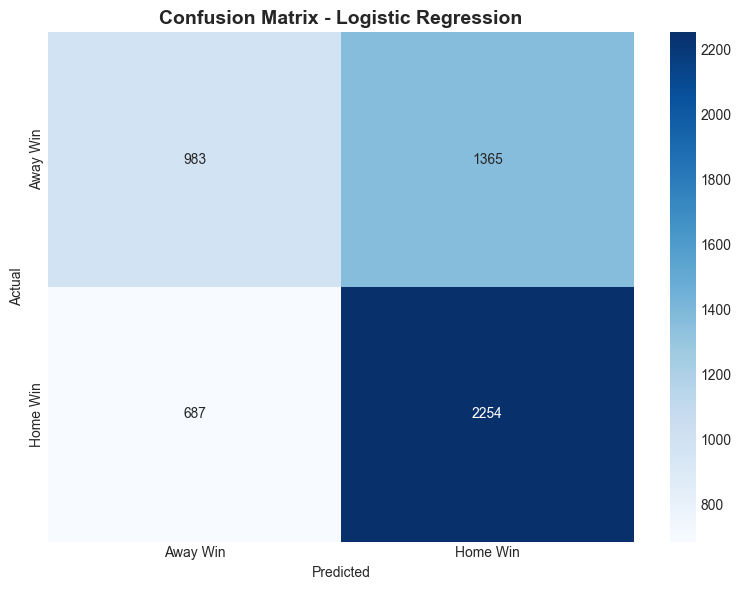


Breakdown:
Correctly predicted home wins:  2,254
Correctly predicted away wins:  983
Missed (predicted home, was away): 1,365
Missed (predicted away, was home): 687


In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Away Win', 'Home Win'],
            yticklabels=['Away Win', 'Home Win'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nBreakdown:")
print(f"Correctly predicted home wins:  {cm[1][1]:,}")
print(f"Correctly predicted away wins:  {cm[0][0]:,}")
print(f"Missed (predicted home, was away): {cm[0][1]:,}")
print(f"Missed (predicted away, was home): {cm[1][0]:,}")

### Model is leaning towards predicting home wins but overpredicts them and misses a lot of away wins
Can probably fix this by adding different features, first lets see if point differential in the last 10 games does anything to improve the model.

In [26]:
# create point differential for each game
df_clean['home_pt_diff'] = df_clean['PTS_home'] - df_clean['PTS_away']

# Rolling average point differential for home team (last 10 home games)
df_clean['home_pt_diff_last10'] = (
    df_clean.groupby('HOME_TEAM_ID')['home_pt_diff']
    .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
)

# For away team, we need to flip it bc their point diff is opposite
df_clean['away_pt_diff_last10'] = (
    df_clean.groupby('VISITOR_TEAM_ID')['home_pt_diff']
    .transform(lambda x: -x.shift(1).rolling(10, min_periods=3).mean())
)

print("Home team avg point differential (last 10):")
print(df_clean['home_pt_diff_last10'].describe().round(2))

print("\nAway team avg point differential (last 10):")
print(df_clean['away_pt_diff_last10'].describe().round(2))

Home team avg point differential (last 10):
count    26462.00
mean         2.81
std          6.14
min        -22.60
25%         -1.40
50%          3.00
75%          7.10
max         23.80
Name: home_pt_diff_last10, dtype: float64

Away team avg point differential (last 10):
count    26462.00
mean        -2.81
std          5.68
min        -22.90
25%         -6.60
50%         -2.90
75%          1.00
max         21.20
Name: away_pt_diff_last10, dtype: float64


## Rebuild and retest model with avg point differential feature

In [28]:
# Update feature list with new features
feature_cols = [
    'home_win_pct_last10', 
    'away_win_pct_last10', 
    'home_rest_days', 
    'away_rest_days',
    'home_pt_diff_last10',
    'away_pt_diff_last10'
]

# Rebuild modeling dataset (drop rows with missing values)
df_model = df_clean.dropna(subset=feature_cols)

# Set up X and y
X = df_model[feature_cols]
y = df_model['HOME_TEAM_WINS']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train both models
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Compare
print(f"Baseline (always home):   {y_test.mean():.1%}")
print(f"Logistic Regression:      {accuracy_lr:.1%}")
print(f"Random Forest:            {accuracy_rf:.1%}")

Baseline (always home):   55.6%
Logistic Regression:      61.8%
Random Forest:            58.8%


## +0.6% to linear regression and +1.7% to random forest
Let's check the confusion matrix again

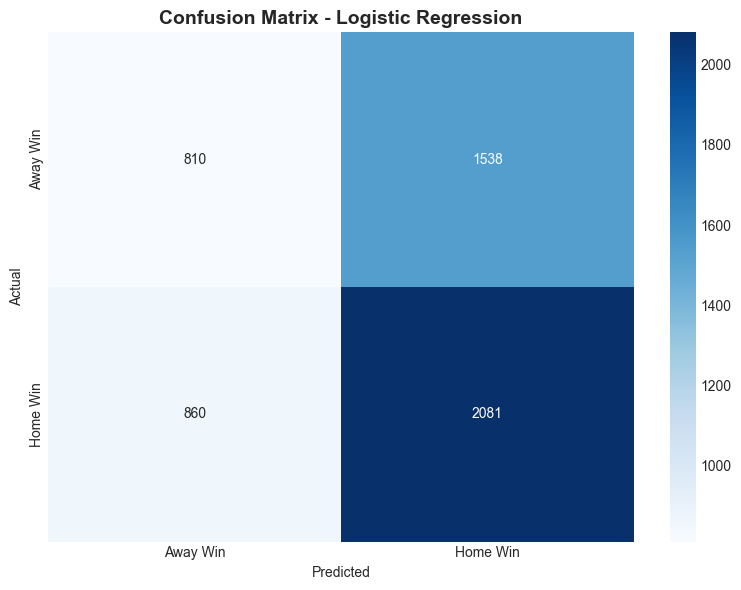


Breakdown:
Correctly predicted home wins:  2,081
Correctly predicted away wins:  810
Missed (predicted home, was away): 1,538
Missed (predicted away, was home): 860


In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Away Win', 'Home Win'],
            yticklabels=['Away Win', 'Home Win'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nBreakdown:")
print(f"Correctly predicted home wins:  {cm[1][1]:,}")
print(f"Correctly predicted away wins:  {cm[0][0]:,}")
print(f"Missed (predicted home, was away): {cm[0][1]:,}")
print(f"Missed (predicted away, was home): {cm[1][0]:,}")

### Model still seems to be heavily favoring the home team to win
Adding more features to see if it impoves

In [30]:
# Back-to-back flag (1 if team played yesterday, 0 if not)
df_clean['home_back_to_back'] = (df_clean['home_rest_days'] == 1).astype(int)
df_clean['away_back_to_back'] = (df_clean['away_rest_days'] == 1).astype(int)

print("Home team back-to-back games:")
print(df_clean['home_back_to_back'].value_counts())

print("\nAway team back-to-back games:")
print(df_clean['away_back_to_back'].value_counts())

def calc_streak(series):
    """Count consecutive wins (positive) or losses (negative)"""
    streak = []
    current = 0
    for val in series:
        if pd.isna(val):
            streak.append(np.nan)
        elif val == 1:
            current = current + 1 if current > 0 else 1
            streak.append(current)
        else:
            current = current - 1 if current < 0 else -1
            streak.append(current)
    return pd.Series(streak, index=series.index)

# Home team streak (shift to avoid data leakage)
df_clean['home_streak'] = (
    df_clean.groupby('HOME_TEAM_ID')['HOME_TEAM_WINS']
    .transform(lambda x: calc_streak(x).shift(1))
)

# Away team streak (remember to flip: home loss = away win)
df_clean['away_streak'] = (
    df_clean.groupby('VISITOR_TEAM_ID')['HOME_TEAM_WINS']
    .transform(lambda x: calc_streak(1 - x).shift(1))
)

print("Home team streak:")
print(df_clean['home_streak'].describe().round(2))

df_clean['home_season_win_pct'] = (
    df_clean.groupby(['HOME_TEAM_ID', 'SEASON'])['HOME_TEAM_WINS']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Season win % for away team
df_clean['away_season_win_pct'] = (
    df_clean.groupby(['VISITOR_TEAM_ID', 'SEASON'])['HOME_TEAM_WINS']
    .transform(lambda x: (1 - x).shift(1).expanding().mean())
)

print("Home team season win %:")
print(df_clean['home_season_win_pct'].describe().round(3))

# Home team's win % specifically at HOME (last 10 home games)
# This is actually what we already have in home_win_pct_last10

# So create AWAY-specific win % for the away team (how they do on the road)
df_clean['away_road_win_pct'] = (
    df_clean.groupby('VISITOR_TEAM_ID')['HOME_TEAM_WINS']
    .transform(lambda x: (1 - x).shift(1).rolling(10, min_periods=3).mean())
)

# And HOME-specific win % for the home team when they're visitors
# (how does the home team do when THEY are on the road?)
df_clean['home_as_visitor_win_pct'] = (
    df_clean.groupby('HOME_TEAM_ID')['HOME_TEAM_WINS']
    .transform(lambda x: (1 - x).shift(1).rolling(10, min_periods=3).mean())
)

print("Away team road win %:")
print(df_clean['away_road_win_pct'].describe().round(3))

Home team back-to-back games:
home_back_to_back
0    25783
1      769
Name: count, dtype: int64

Away team back-to-back games:
away_back_to_back
0    22584
1     3968
Name: count, dtype: int64
Home team streak:
count    26522.00
mean         0.97
std          3.65
min        -18.00
25%         -1.00
50%          1.00
75%          2.00
max         40.00
Name: home_streak, dtype: float64
Home team season win %:
count    25953.000
mean         0.592
std          0.203
min          0.000
25%          0.467
50%          0.605
75%          0.731
max          1.000
Name: home_season_win_pct, dtype: float64
Away team road win %:
count    26462.000
mean         0.411
std          0.198
min          0.000
25%          0.300
50%          0.400
75%          0.500
max          1.000
Name: away_road_win_pct, dtype: float64


In [32]:
feature_cols = [
    'home_win_pct_last10', 
    'away_win_pct_last10', 
    'home_rest_days', 
    'away_rest_days',
    'home_pt_diff_last10',
    'away_pt_diff_last10',
    'home_back_to_back',
    'away_back_to_back',
    'home_streak',           # NEW
    'away_streak',           # NEW
    'home_season_win_pct',   # NEW
    'away_season_win_pct',   # NEW
    'away_road_win_pct',     # NEW
    'home_as_visitor_win_pct' # NEW
]

# Rebuild modeling dataset (drop rows with missing values)
df_model = df_clean.dropna(subset=feature_cols)
print(f"Games ready for modeling: {len(df_model):,}")

# Set up X and y
X = df_model[feature_cols]
y = df_model['HOME_TEAM_WINS']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Train both models
model_lr = LogisticRegression(random_state=42, max_iter = 1000)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Compare
print(f"Baseline (always home):   {y_test.mean():.1%}")
print(f"Logistic Regression:      {accuracy_lr:.1%}")
print(f"Random Forest:            {accuracy_rf:.1%}")

Games ready for modeling: 25,690
Baseline (always home):   55.8%
Logistic Regression:      62.5%
Random Forest:            61.6%


## Which feature make the most impact?

In [34]:
# Logistic Regression coefficients (absolute value)
lr_importance = np.abs(model_lr.coef_[0])

# Random Forest importance
rf_importance = model_rf.feature_importances_

# Create comparison table
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'LogReg': lr_importance,
    'RandomForest': rf_importance,
}).round(3)

# Sort by Logistic Regression importance
importance_df = importance_df.sort_values('LogReg', ascending=False)
print(importance_df.to_string(index=False))

                Feature  LogReg  RandomForest
    away_season_win_pct   1.071         0.136
    home_season_win_pct   0.918         0.137
      away_back_to_back   0.129         0.011
      home_back_to_back   0.119         0.003
    home_pt_diff_last10   0.066         0.145
    home_win_pct_last10   0.048         0.038
    away_pt_diff_last10   0.047         0.139
home_as_visitor_win_pct   0.009         0.036
         away_rest_days   0.007         0.068
         home_rest_days   0.004         0.067
    away_win_pct_last10   0.002         0.038
            home_streak   0.002         0.073
            away_streak   0.002         0.072
      away_road_win_pct   0.002         0.036


Season win % for logistic regression, back-to-back matters for logisitc regression, and streaks don't really matter

## Checking the top 4 features from the logistic regression model and seeing how it compares to the 16 feature model

In [35]:
# Top 4 features only
feature_cols_slim = [
    'home_season_win_pct',
    'away_season_win_pct',
    'home_pt_diff_last10',
    'away_pt_diff_last10'
]

# Rebuild dataset
df_model_slim = df_clean.dropna(subset=feature_cols_slim)

X_slim = df_model_slim[feature_cols_slim]
y_slim = df_model_slim['HOME_TEAM_WINS']

X_train_slim, X_test_slim, y_train_slim, y_test_slim = train_test_split(
    X_slim, y_slim, test_size=0.2, shuffle=False
)

# Train Logistic Regression
model_lr_slim = LogisticRegression(random_state=42, max_iter=1000)
model_lr_slim.fit(X_train_slim, y_train_slim)
y_pred_slim = model_lr_slim.predict(X_test_slim)
accuracy_slim = accuracy_score(y_test_slim, y_pred_slim)

print(f"4 feature model")
print(f"Baseline:                 {y_test_slim.mean():.1%}")
print(f"Logistic Regression:      {accuracy_slim:.1%}")
print(f"\nCompare to 14-feature model: {accuracy_lr:.1%}")

4 feature model
Baseline:                 55.8%
Logistic Regression:      62.4%

Compare to 14-feature model: 62.5%


## Only a .1% increase from 4 features to 14 features...

In [36]:
# Cross-validation (tests model stability across different data splits)
cv_scores = cross_val_score(model_lr_slim, X_slim, y_slim, cv=5, scoring='accuracy')

print("Cross-Validation Results (5 folds)")
print(f"Scores: {[f'{s:.1%}' for s in cv_scores]}")
print(f"Mean:   {cv_scores.mean():.1%}")
print(f"Std:    {cv_scores.std():.1%}")

Cross-Validation Results (5 folds)
Scores: ['63.0%', '66.6%', '65.3%', '64.0%', '63.6%']
Mean:   64.5%
Std:    1.3%


# Using google to see what the best stats are to use for predicting nba games
https://www.nbastuffer.com/nba-metrics-for-outcome-predictions/
So we'll check a model with:
1. net rating
2. assist-to-turnover ratio
3. rebounding%
4. eFG%
5. pace
6. offensive rating
7. defensive rating
8. true shooting %
9. turnover %

Currently games.csv doesn't track these metrics but the nba_api does and has a good amount of game history to train on

In [39]:
from nba_api.stats.endpoints import leaguedashteamstats

# Pull advanced team stats for current season
advanced_stats = leaguedashteamstats.LeagueDashTeamStats(
    season='2025-26',
    measure_type_detailed_defense='Advanced',
    per_mode_detailed='PerGame'
)

df_advanced = advanced_stats.get_data_frames()[0]

print(f"Columns available ({len(df_advanced.columns)}):\n")
print(df_advanced.columns.tolist())

Columns available (46):

['TEAM_ID', 'TEAM_NAME', 'GP', 'W', 'L', 'W_PCT', 'MIN', 'E_OFF_RATING', 'OFF_RATING', 'E_DEF_RATING', 'DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'AST_PCT', 'AST_TO', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT', 'EFG_PCT', 'TS_PCT', 'E_PACE', 'PACE', 'PACE_PER40', 'POSS', 'PIE', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'OFF_RATING_RANK', 'DEF_RATING_RANK', 'NET_RATING_RANK', 'AST_PCT_RANK', 'AST_TO_RANK', 'AST_RATIO_RANK', 'OREB_PCT_RANK', 'DREB_PCT_RANK', 'REB_PCT_RANK', 'TM_TOV_PCT_RANK', 'EFG_PCT_RANK', 'TS_PCT_RANK', 'PACE_RANK', 'PIE_RANK']


In [40]:
# See current team stats
print(df_advanced[['TEAM_NAME', 'NET_RATING', 'OFF_RATING', 'DEF_RATING', 
                   'EFG_PCT', 'PACE', 'AST_TO', 'OREB_PCT', 'DREB_PCT']].sort_values('NET_RATING', ascending=False).head(10))

                 TEAM_NAME  NET_RATING  OFF_RATING  DEF_RATING  EFG_PCT  \
20   Oklahoma City Thunder        12.0       118.1       106.1    0.565   
8          Detroit Pistons         8.3       116.6       108.3    0.542   
1           Boston Celtics         7.5       120.2       112.6    0.551   
19         New York Knicks         6.1       118.9       112.8    0.554   
26       San Antonio Spurs         6.1       117.0       110.9    0.550   
10         Houston Rockets         5.0       117.0       112.0    0.534   
17  Minnesota Timberwolves         4.6       117.0       112.4    0.564   
5      Cleveland Cavaliers         4.1       117.5       113.3    0.556   
7           Denver Nuggets         4.1       121.0       116.9    0.574   
15              Miami Heat         2.1       113.7       111.6    0.533   

      PACE  AST_TO  OREB_PCT  DREB_PCT  
20  100.80    2.06     0.257     0.695  
8   100.35    1.75     0.352     0.692  
1    95.70    1.98     0.338     0.691  
19   98.67

In [ ]:
### This is showing current SEASON totals, but we need game-by-game stats for each matchup

In [42]:
from nba_api.stats.endpoints import teamgamelogs

game_logs = teamgamelogs.TeamGameLogs(
    season_nullable='2025-26',
    season_type_nullable='Regular Season'
)

df_logs = game_logs.get_data_frames()[0]

print(f"Games pulled: {len(df_logs)}")
print(f"\nColumns:")
print(df_logs.columns.tolist())

Games pulled: 1632

Columns:
['SEASON_YEAR', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'AVAILABLE_FLAG']


In [43]:
# Calculate advanced stats from game logs
df_logs['GAME_DATE'] = pd.to_datetime(df_logs['GAME_DATE'])
df_logs = df_logs.sort_values('GAME_DATE').reset_index(drop=True)

# 1. eFG% = (FGM + 0.5 * FG3M) / FGA
df_logs['EFG_PCT'] = (df_logs['FGM'] + 0.5 * df_logs['FG3M']) / df_logs['FGA']

# 2. AST/TOV ratio
df_logs['AST_TO'] = df_logs['AST'] / df_logs['TOV'].replace(0, 1)

# 3. Free Throw Rate = FTA / FGA  
df_logs['FT_RATE'] = df_logs['FTA'] / df_logs['FGA']

# 4. Create rolling averages (last 10 games)
stat_cols = ['PLUS_MINUS', 'EFG_PCT', 'AST_TO', 'FT_RATE', 'OREB', 'DREB']

for col in stat_cols:
    df_logs[f'{col}_L10'] = (
        df_logs.groupby('TEAM_ID')[col]
        .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
    )

print("Advanced stats calculated!")
print(df_logs[['TEAM_ABBREVIATION', 'GAME_DATE', 'PLUS_MINUS_L10', 'EFG_PCT_L10', 'AST_TO_L10']].tail(10))

✅ Advanced stats calculated!
     TEAM_ABBREVIATION  GAME_DATE  PLUS_MINUS_L10  EFG_PCT_L10  AST_TO_L10
1622               NOP 2026-02-11             1.5     0.520817    2.377297
1623               GSW 2026-02-11            -3.6     0.550182    1.788874
1624               TOR 2026-02-11             4.7     0.558930    2.154040
1625               POR 2026-02-11            -1.7     0.544614    1.416505
1626               WAS 2026-02-11            -9.4     0.520000    1.652382
1627               PHX 2026-02-11            -0.1     0.536793    1.954287
1628               SAC 2026-02-11           -10.8     0.509687    1.637788
1629               PHI 2026-02-11             0.8     0.554925    2.498062
1630               ATL 2026-02-11            -0.2     0.550609    2.436930
1631               NYK 2026-02-11            10.7     0.555458    2.364939


In [45]:
from nba_api.stats.endpoints import leaguegamefinder

gamefinder = leaguegamefinder.LeagueGameFinder(
    season_nullable='2025-26',
    league_id_nullable='00',
    season_type_nullable='Regular Season'
)
games_df = gamefinder.get_data_frames()[0]

home_games = games_df[games_df['MATCHUP'].str.contains('vs.')].copy()
away_games = games_df[games_df['MATCHUP'].str.contains('@')].copy()

df_2026 = home_games.merge(away_games, on='GAME_ID', suffixes=('_home', '_away'))
df_2026['HOME_TEAM_WINS'] = (df_2026['WL_home'] == 'W').astype(int)
df_2026 = df_2026.rename(columns={
    'TEAM_ID_home': 'HOME_TEAM_ID',
    'TEAM_ID_away': 'VISITOR_TEAM_ID'
})

In [47]:
# Separate home and away games
df_logs['is_home'] = df_logs['MATCHUP'].str.contains('vs.').astype(int)

home_stats = df_logs[df_logs['is_home'] == 1][['GAME_ID', 'TEAM_ID', 'PLUS_MINUS_L10', 'EFG_PCT_L10', 'AST_TO_L10', 'FT_RATE_L10', 'OREB_L10', 'DREB_L10']].copy()
home_stats.columns = ['GAME_ID', 'HOME_TEAM_ID', 'home_pm_L10', 'home_efg_L10', 'home_ast_to_L10', 'home_ftr_L10', 'home_oreb_L10', 'home_dreb_L10']

away_stats = df_logs[df_logs['is_home'] == 0][['GAME_ID', 'TEAM_ID', 'PLUS_MINUS_L10', 'EFG_PCT_L10', 'AST_TO_L10', 'FT_RATE_L10', 'OREB_L10', 'DREB_L10']].copy()
away_stats.columns = ['GAME_ID', 'VISITOR_TEAM_ID', 'away_pm_L10', 'away_efg_L10', 'away_ast_to_L10', 'away_ftr_L10', 'away_oreb_L10', 'away_dreb_L10']

# Merge with df_2026
df_2026_adv = df_2026.merge(home_stats, on=['GAME_ID', 'HOME_TEAM_ID'], how='left')
df_2026_adv = df_2026_adv.merge(away_stats, on=['GAME_ID', 'VISITOR_TEAM_ID'], how='left')

# Define new feature set
adv_features = [
    'home_pm_L10', 'away_pm_L10',           # Plus/minus (like net rating)
    'home_efg_L10', 'away_efg_L10',         # Shooting efficiency
    'home_ast_to_L10', 'away_ast_to_L10',   # Ball security
    'home_ftr_L10', 'away_ftr_L10',         # Free throw rate
    'home_oreb_L10', 'away_oreb_L10',       # Offensive rebounding
    'home_dreb_L10', 'away_dreb_L10'        # Defensive rebounding
]

# Prepare and train
df_2026_model = df_2026_adv.dropna(subset=adv_features)
X_adv = df_2026_model[adv_features]
y_adv = df_2026_model['HOME_TEAM_WINS']

X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_adv, y_adv, test_size=0.2, shuffle=False
)

model_adv = LogisticRegression(random_state=42, max_iter=1000)
model_adv.fit(X_train_adv, y_train_adv)
accuracy_adv = accuracy_score(y_test_adv, model_adv.predict(X_test_adv))

print(f"Games used:              {len(df_2026_model)}")
print(f"Baseline (pick home):    {y_test_adv.mean():.1%}")
print(f"Advanced model:          {accuracy_adv:.1%}")
print(f"Original model:     61.6%")

Games used:              763
Baseline (pick home):    56.2%
Advanced model:          67.3%
Original model:     61.6%


In [48]:
# Feature importance
importance = pd.DataFrame({
    'Feature': adv_features,
    'Coefficient': np.abs(model_adv.coef_[0])
}).sort_values('Coefficient', ascending=False)

print("📊 Feature Importance (Advanced Model)")
print("="*40)
print(importance.to_string(index=False))

📊 Feature Importance (Advanced Model)
        Feature  Coefficient
away_ast_to_L10     0.397764
   away_ftr_L10     0.369592
   home_ftr_L10     0.281045
   away_efg_L10     0.195619
home_ast_to_L10     0.160784
   home_efg_L10     0.075855
    away_pm_L10     0.073407
    home_pm_L10     0.051434
  away_dreb_L10     0.043472
  away_oreb_L10     0.024025
  home_dreb_L10     0.023173
  home_oreb_L10     0.001824


### Important features
1. ball security
2. free throws
3. efg%

In [49]:
# Cross-validation on advanced model
cv_scores = cross_val_score(model_adv, X_adv, y_adv, cv=5, scoring='accuracy')

print("Cross-Validation Results (Advanced Model)")
print(f"{'='*45}")
print(f"Scores: {[f'{s:.1%}' for s in cv_scores]}")
print(f"Mean:   {cv_scores.mean():.1%}")
print(f"Std:    {cv_scores.std():.1%}")
print(f"{'='*45}")

print(f"\nCompare to original model:")
print(f"Original - Mean: 64.5%, Std: 1.3%")

Cross-Validation Results (Advanced Model)
Scores: ['63.4%', '55.6%', '53.6%', '70.4%', '67.8%']
Mean:   62.1%
Std:    6.6%

Compare to original model:
Original - Mean: 64.5%, Std: 1.3%


# Need to train on more games, original model was trained on like 26000 games whereas this model was trained on 700 games

In [51]:
from nba_api.stats.endpoints import teamgamelogs
import time

# Pull game logs for multiple seasons
seasons = ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', 
           '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']

all_logs = []

for season in seasons:
    print(f"Pulling {season}...")
    try:
        logs = teamgamelogs.TeamGameLogs(
            season_nullable=season,
            season_type_nullable='Regular Season'
        )
        df = logs.get_data_frames()[0]
        df['SEASON'] = season
        all_logs.append(df)
        time.sleep(1)  # Be nice to the API
    except Exception as e:
        print(f"  Error: {e}")

# Combine all seasons
df_historical = pd.concat(all_logs, ignore_index=True)
print(f"Seasons pulled: {df_historical['SEASON'].nunique()}")

Pulling 2015-16...
Pulling 2016-17...
Pulling 2017-18...
Pulling 2018-19...
Pulling 2019-20...
Pulling 2020-21...
Pulling 2021-22...
Pulling 2022-23...
Pulling 2023-24...
Pulling 2024-25...
Pulling 2025-26...
Seasons pulled: 11


# Calculate the advanced stats on all of the game data

In [53]:
# Sort by date
df_historical['GAME_DATE'] = pd.to_datetime(df_historical['GAME_DATE'])
df_historical = df_historical.sort_values('GAME_DATE').reset_index(drop=True)

# Calculate advanced metrics
df_historical['EFG_PCT'] = (df_historical['FGM'] + 0.5 * df_historical['FG3M']) / df_historical['FGA']
df_historical['AST_TO'] = df_historical['AST'] / df_historical['TOV'].replace(0, 1)
df_historical['FT_RATE'] = df_historical['FTA'] / df_historical['FGA']

# Rolling averages (last 10 games)
stat_cols = ['PLUS_MINUS', 'EFG_PCT', 'AST_TO', 'FT_RATE', 'OREB', 'DREB']
for col in stat_cols:
    df_historical[f'{col}_L10'] = (
        df_historical.groupby('TEAM_ID')[col]
        .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
    )

# Separate home/away
df_historical['is_home'] = df_historical['MATCHUP'].str.contains('vs.').astype(int)

print(f"Sample of data:")
print(df_historical[['TEAM_ABBREVIATION', 'GAME_DATE', 'PLUS_MINUS_L10', 'EFG_PCT_L10', 'AST_TO_L10']].tail(10))

Sample of data:
      TEAM_ABBREVIATION  GAME_DATE  PLUS_MINUS_L10  EFG_PCT_L10  AST_TO_L10
25580               MIL 2026-02-11            -6.8     0.557486    2.041668
25581               MIN 2026-02-11             3.3     0.561858    1.794309
25582               MIA 2026-02-11             8.3     0.522033    2.175777
25583               SAS 2026-02-11             8.2     0.558540    2.183580
25584               DET 2026-02-11             9.8     0.545798    2.415694
25585               BOS 2026-02-11             5.6     0.515423    2.494708
25586               NYK 2026-02-11            10.7     0.555458    2.364939
25587               ATL 2026-02-11            -0.2     0.550609    2.436930
25588               HOU 2026-02-11             1.2     0.502273    1.907537
25589               CLE 2026-02-11            11.9     0.570552    2.285452


# Train the new model

In [54]:
# Separate home and away games
home_stats = df_historical[df_historical['is_home'] == 1][['GAME_ID', 'TEAM_ID', 'WL', 'PLUS_MINUS_L10', 'EFG_PCT_L10', 'AST_TO_L10', 'FT_RATE_L10', 'OREB_L10', 'DREB_L10']].copy()
home_stats.columns = ['GAME_ID', 'HOME_TEAM_ID', 'WL_home', 'home_pm_L10', 'home_efg_L10', 'home_ast_to_L10', 'home_ftr_L10', 'home_oreb_L10', 'home_dreb_L10']

away_stats = df_historical[df_historical['is_home'] == 0][['GAME_ID', 'TEAM_ID', 'PLUS_MINUS_L10', 'EFG_PCT_L10', 'AST_TO_L10', 'FT_RATE_L10', 'OREB_L10', 'DREB_L10']].copy()
away_stats.columns = ['GAME_ID', 'VISITOR_TEAM_ID', 'away_pm_L10', 'away_efg_L10', 'away_ast_to_L10', 'away_ftr_L10', 'away_oreb_L10', 'away_dreb_L10']

# Merge home and away
df_games = home_stats.merge(away_stats, on='GAME_ID', how='inner')
df_games['HOME_TEAM_WINS'] = (df_games['WL_home'] == 'W').astype(int)

# Define features and train
adv_features = [
    'home_pm_L10', 'away_pm_L10',
    'home_efg_L10', 'away_efg_L10',
    'home_ast_to_L10', 'away_ast_to_L10',
    'home_ftr_L10', 'away_ftr_L10',
    'home_oreb_L10', 'away_oreb_L10',
    'home_dreb_L10', 'away_dreb_L10'
]

df_model_hist = df_games.dropna(subset=adv_features)
X_hist = df_model_hist[adv_features]
y_hist = df_model_hist['HOME_TEAM_WINS']

X_train_hist, X_test_hist, y_train_hist, y_test_hist = train_test_split(
    X_hist, y_hist, test_size=0.2, shuffle=False
)

model_hist = LogisticRegression(random_state=42, max_iter=1000)
model_hist.fit(X_train_hist, y_train_hist)
accuracy_hist = accuracy_score(y_test_hist, model_hist.predict(X_test_hist))


print(f"Training games:          {len(X_train_hist):,}")
print(f"Test games:              {len(X_test_hist):,}")
print(f"Baseline (pick home):    {y_test_hist.mean():.1%}")
print(f"Model accuracy:          {accuracy_hist:.1%}")
print(f"{'='*50}")
print(f"\nCompare to previous:")
print(f"Original model (4 feat):     62.4%")
print(f"Advanced (715 games):        69.9%")
print(f"Advanced (full history):     {accuracy_hist:.1%}")

Training games:          10,190
Test games:              2,548
Baseline (pick home):    53.8%
Model accuracy:          63.2%

Compare to previous:
Original model (4 feat):     62.4%
Advanced (715 games):        69.9%
Advanced (full history):     63.2%


In [55]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model_hist, X_hist, y_hist, cv=5, scoring='accuracy')

print("Cross-Validation Results (Advanced Model - Full History)")
print(f"{'='*50}")
print(f"Scores: {[f'{s:.1%}' for s in cv_scores]}")
print(f"Mean:   {cv_scores.mean():.1%}")
print(f"Std:    {cv_scores.std():.1%}")
print(f"{'='*50}")

Cross-Validation Results (Advanced Model - Full History)
Scores: ['62.8%', '63.2%', '61.6%', '62.1%', '63.5%']
Mean:   62.6%
Std:    0.7%


## Settled on 12 feature advanced model that has 63.2% accuracy compared to a baseline of 53.8% of if I just picked the home team to win each time.
+9.4% improvement from baseline
10,000+ games of training data
Cross validation: 62.6% (+/- 0.7%)